In [1]:
import pandas as pd
import numpy as np
import os
import json
from scipy import constants
import matplotlib.pyplot as plt
import sympy
import random
from ase.io import read

/home/paolo/.conda/envs/pymc_env/lib/python3.12/site-packages/numpy/_core/getlimits.py:552: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [2]:
from sympy import symbols, simplify, sin, expand
import sympy as sp
import pymc as pm
import arviz as az

In [3]:
atoms_train = read("/home/paolo/Na_dataset/train_Na_new.xyz", index=":")
atoms_test = read("/home/paolo/Na_dataset/test_Na_new.xyz", index=":")

In [4]:
data_train = pd.concat(
    [pd.DataFrame([a.info for a in atoms_train]),
     pd.DataFrame({'cub_root_V': [a.get_volume()**(1/3) for a in atoms_train]})],
    axis=1
)
data_test = pd.concat(
    [pd.DataFrame([a.info for a in atoms_test]),
     pd.DataFrame({'cub_root_V': [a.get_volume()**(1/3) for a in atoms_test]})],
    axis=1
)

In [5]:
def initialize_units(df_iniz, med_flag = False):
    df = (df_iniz - df_iniz.mean()) / df_iniz.std()
    kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
    return {
        "E" : np.array(df['Ea'], dtype = 'float'),
        "cub_root_V" : np.array(df['cub_root_V'], dtype = 'float'),
        
        # Density in g/cm^3
        "density": np.array(df['density'], dtype='float'),
        # Average Atomic Volume
        "AAV": np.array(df['AAV'], dtype='float'),
        # Volume per anion
        "VPA": np.array(df['VPA'], dtype='float'),
        # -Na-Na (are just the Na-Na distances)
        "Na-Na": np.array(df['Na-Na'], dtype='float'),
        "Na-Na-max": np.array(df['Na-Na-max'], dtype='float'),
        "Na-Na-avg": np.array(df['Na-Na-avg'], dtype='float'),
        # -bottleneck (free distance available for a Na⁺ ion to pass through the narrowest part of a diffusion pathway formed by surrounding framework atoms (typically O²⁻, S²⁻, or halides))
        "bottleneck_min": np.array(df['bottleneck_min'], dtype='float'),
        "bottleneck_avg": np.array(df['bottleneck_avg'], dtype='float'),
        # -face-area   (area of the shared face between two neighboring Voronoi polyhedra corresponding to adjacent Na sites it represents the cross-sectional area available for Na⁺ migration between those sites)
        "face-area-max": np.array(df['face-area-max'], dtype='float'),
        "face-area-avg": np.array(df['face-area-avg'], dtype='float'),
        "face-area-min": np.array(df['face-area-min'], dtype='float'),
        # -pockets  (free-volume region in the crystal structure where a Na⁺ ion can reside with relatively low energy, typically corresponding to a stable or metastable Na site)
        "pockets-per-volume": np.array(df['pockets-per-volume'], dtype='float'),
        # -paths  (connected sequence of pockets linked by Voronoi faces and constrained by bottlenecks, forming a continuous route that allows Na⁺ ions to move through the crystal lattice)
        "paths-per-volume": np.array(df['paths-per-volume'], dtype='float')
    }

In [6]:
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
data = initialize_units(data_train)
T = 300
lnDvsE = pd.DataFrame({
    "sample_id": [f"s{j+1}" for j in range(len(data_train['Ea']))], 
    "E_T": data_train['Ea']/(kb*T),
    "rho": data['density'],
    "AAV": data['AAV'],
    "PF": data_train['PF'],
    "VPA": data['VPA'],
    "NBI": data_train['NBI'],
    "SBI": data_train['SBI'],
    "RBI": data_train['RBI'],
    "WE": data_train['weighted_electronegativity'],
    "B": data_train['B'],
    "N": data_train['N'],
    "S": data_train['S'],
    "O": data_train['O'],
    "F": data_train['F'],
    "Na": data_train['Na'],
    "Al": data_train['Al'],
    "Si": data_train['Si'],
    "P": data_train['P'],
    "Cl": data_train['Cl'],
    "Ge": data_train['Ge'],
    "Br": data_train['Br'],
    "I": data_train['I'],

    # Volume
    "cub_root_V" : data['cub_root_V'],
    
    # Na–Na distances
    "Na-Na": data['Na-Na'],
    "Na-Na-max": data['Na-Na-max'],
    "Na-Na-avg": data['Na-Na-avg'],

    # Bottleneck descriptors
    "bottleneck_min": data['bottleneck_min'],
    "bottleneck_avg": data['bottleneck_avg'],

    # Polyhedral distortion
    "poly_dist_max": data_train['poly_dist_max'],
    "poly_dist_std": data_train['poly_dist_std'],
    "poly_dist_avg": data_train['poly_dist_avg'],
    "poly_dist_avg_fixed": data_train['poly_dist_avg_fixed'],

    # Voronoi face areas
    "face-area-max": data['face-area-max'],
    "face-area-avg": data['face-area-avg'],
    "face-area-min": data['face-area-min'],
    "face-area-count": data_train['face-area-count'],

    # Pockets
    "pockets-per-ion": data_train['pockets-per-ion'],
    "pockets-per-volume": data['pockets-per-volume'],

    # Paths
    "paths-per-ion": data_train['paths-per-ion'],
    "paths-per-volume": data['paths-per-volume'],

    # Target
    "ln_D": data_train['logD']
})    

In [7]:
n_feat = 40
lnDvsE.to_csv(f"/home/paolo/Thesis/Na/data/final/Na_lndiff{n_feat}_temp300_unitless3.csv", index=False)
data_file = f"/home/paolo/Thesis/Na/data/final/Na_lndiff{n_feat}_temp300_unitless3.csv"
os.environ["SISSOPP_TUT_DAT_FILE"] = data_file

In [8]:
# Try the fit with the exact functional form
rung = 2
desc_dim = 3
Diff_json = {
    'data_file': data_file,
     'property_key': 'ln_D',
     'desc_dim': desc_dim,
     'n_sis_select': 10,
     'max_rung': rung,
     'calc_type': 'regression',
     'min_abs_feat_val': 1e-05,
     'max_abs_feat_val': 1e8,
     'n_residual': 10,
     'n_models_store': 10,
     'leave_out_frac': 0.0,
     'leave_out_inds': [],
     'opset': ['exp', 'add', 'sub', 'mult', 'div']
}
json.dump(Diff_json, open(f"/home/paolo/Thesis/Na/data/final/lndiff{n_feat}_{rung}_{desc_dim}_unitless.json", "w"), indent=4)

In [9]:
def extract_rung2_dd3_(ms = 10, rung=2, feat = 40):
    '''Extract the formulas and the values of the parameters from the SISSO output for desc_dim=3'''
    dd = 3
    formulas = []
    a0_list = []
    a1_list = []
    a2_list = []
    c0_list = []
    models_stored = ms
    for i in range(models_stored):
        filename = f'/home/paolo/Thesis/Na/data/final/models_lndiff{feat}_{rung}_{dd}_unitless/train_dim_{dd}_model_{i}.dat'
        with open(filename, 'r') as f:
            line1 = next(f)               # First line
            for _ in range(4): next(f)    # Skip lines 2 to 5
            line6 = next(f)               # Sixth line
            formula = line1.replace('#', '').strip()
            # Split line6 by spaces
            parts = line6.strip().split()
            a0_i = parts[3].rstrip(',')
            a1_i = parts[4].rstrip(',')
            a2_i = parts[5].rstrip(',')
            c0_i = parts[6].rstrip(',')
    
            formulas.append(formula)
            a0_list.append(a0_i)
            a1_list.append(a1_i)
            a2_list.append(a2_i)
            c0_list.append(c0_i)
            #print(formula, a0_i, a1_i, c0_i)
    return(formulas, a0_list, a1_list, a2_list, c0_list)

In [10]:
raw_formulas, a0_list, a1_list, a2_list, c0_list = extract_rung2_dd3_()
raw_formulas

['c0 + a0 * ((P * O) + (Na * S)) + a1 * ((rho / E_T) + (Si + Al)) + a2 * ((O * WE) - (face-area-avg - E_T))',
 'c0 + a0 * ((S * PF) + (poly_dist_avg_fixed * O)) + a1 * ((rho / E_T) + (Si + Al)) + a2 * ((S - E_T) + (face-area-avg - O))',
 'c0 + a0 * ((S * PF) + (poly_dist_avg_fixed * O)) + a1 * ((rho / E_T) + (Si + Al)) + a2 * ((O * WE) - (face-area-avg - E_T))',
 'c0 + a0 * ((S * PF) + (poly_dist_avg_fixed * O)) + a1 * ((rho / E_T) + (Si + Al)) + a2 * ((O + E_T) - (face-area-avg - O))',
 'c0 + a0 * ((S * PF) + (poly_dist_avg_fixed * poly_dist_avg)) + a1 * ((rho / E_T) + (Si + Al)) + a2 * ((O * WE) - (face-area-avg - E_T))',
 'c0 + a0 * ((Al + Na) * (S * PF)) + a1 * ((rho / E_T) + (Si + Al)) + a2 * ((O * WE) - (face-area-avg - E_T))',
 'c0 + a0 * ((Na - O) * (poly_dist_avg - S)) + a1 * ((rho / E_T) + (Si + Al)) + a2 * ((O / NBI) - (face-area-avg - E_T))',
 'c0 + a0 * ((O - S) * (poly_dist_avg - Na)) + a1 * ((rho / E_T) + (Si + Al)) + a2 * ((face-area-avg - E_T) - (poly_dist_avg + O))',


In [11]:
def sanitize(expr):
    return (
        expr
        .replace('Na-Na-avg', 'Na_Na_avg')
        .replace('Na-Na-max', 'Na_Na_max')
        .replace('Na-Na', 'Na_Na')
        .replace('face-area-avg', 'face_area_avg')
        .replace('face-area-max', 'face_area_max')
        .replace('face-area-min', 'face_area_min')
        .replace('face-area-count', 'face_area_count')
        .replace('cub_root_V', 'cub_root_V')
        .replace('pockets-per-ion', 'pockets_per_ion')
        .replace('pockets-per-volume', 'pockets_per_volume')
        .replace('paths-per-ion', 'paths_per_ion')
        .replace('paths-per-volume', 'paths_per_volume')
    )

In [12]:
formulas = [sanitize(f) for f in raw_formulas]
formulas

['c0 + a0 * ((P * O) + (Na * S)) + a1 * ((rho / E_T) + (Si + Al)) + a2 * ((O * WE) - (face_area_avg - E_T))',
 'c0 + a0 * ((S * PF) + (poly_dist_avg_fixed * O)) + a1 * ((rho / E_T) + (Si + Al)) + a2 * ((S - E_T) + (face_area_avg - O))',
 'c0 + a0 * ((S * PF) + (poly_dist_avg_fixed * O)) + a1 * ((rho / E_T) + (Si + Al)) + a2 * ((O * WE) - (face_area_avg - E_T))',
 'c0 + a0 * ((S * PF) + (poly_dist_avg_fixed * O)) + a1 * ((rho / E_T) + (Si + Al)) + a2 * ((O + E_T) - (face_area_avg - O))',
 'c0 + a0 * ((S * PF) + (poly_dist_avg_fixed * poly_dist_avg)) + a1 * ((rho / E_T) + (Si + Al)) + a2 * ((O * WE) - (face_area_avg - E_T))',
 'c0 + a0 * ((Al + Na) * (S * PF)) + a1 * ((rho / E_T) + (Si + Al)) + a2 * ((O * WE) - (face_area_avg - E_T))',
 'c0 + a0 * ((Na - O) * (poly_dist_avg - S)) + a1 * ((rho / E_T) + (Si + Al)) + a2 * ((O / NBI) - (face_area_avg - E_T))',
 'c0 + a0 * ((O - S) * (poly_dist_avg - Na)) + a1 * ((rho / E_T) + (Si + Al)) + a2 * ((face_area_avg - E_T) - (poly_dist_avg + O))',


In [13]:
a0 = np.array(a0_list, dtype=float)
a1 = np.array(a1_list, dtype=float)
a2 = np.array(a2_list, dtype=float)
c0 = np.array(c0_list, dtype=float)

In [14]:
# define symbols
a0_sym, a1_sym, a2_sym, c0_sym = sp.symbols('a0 a1 a2 c0')
symbols = sp.symbols(
    '''
    E_T B N O F Na Al Si P S Cl Ge Br I
    rho AAV PF SBI RBI VPA NBI WE cub_root_V
    bottleneck_min bottleneck_avg
    poly_dist_avg poly_dist_max poly_dist_std poly_dist_avg_fixed
    Na_Na Na_Na_max Na_Na_avg
    face_area_max face_area_avg face_area_min face_area_count
    pockets_per_ion pockets_per_volume
    paths_per_ion paths_per_volume
    '''
)

locals_dict = {s.name: s for s in symbols}
# convert strings to sympy expressions
sympy_exprs = [sp.sympify(f, locals=locals_dict) for f in formulas]

pruned = []
# Prunes the coefficients that will be added later as distributions
for f in sympy_exprs:
    row = [
        sp.simplify(f.coeff(a0_sym)),
        sp.simplify(f.coeff(a1_sym)),
        sp.simplify(f.coeff(a2_sym)),
    ]
    pruned.append(row)

pruned

[[Na*S + O*P, Al + Si + rho/E_T, E_T + O*WE - face_area_avg],
 [O*poly_dist_avg_fixed + PF*S,
  Al + Si + rho/E_T,
  -E_T - O + S + face_area_avg],
 [O*poly_dist_avg_fixed + PF*S, Al + Si + rho/E_T, E_T + O*WE - face_area_avg],
 [O*poly_dist_avg_fixed + PF*S, Al + Si + rho/E_T, E_T + 2*O - face_area_avg],
 [PF*S + poly_dist_avg*poly_dist_avg_fixed,
  Al + Si + rho/E_T,
  E_T + O*WE - face_area_avg],
 [PF*S*(Al + Na), Al + Si + rho/E_T, E_T + O*WE - face_area_avg],
 [-(Na - O)*(S - poly_dist_avg),
  Al + Si + rho/E_T,
  E_T - face_area_avg + O/NBI],
 [-(Na - poly_dist_avg)*(O - S),
  Al + Si + rho/E_T,
  -E_T - O + face_area_avg - poly_dist_avg],
 [-(Na - O)*(S - poly_dist_avg_fixed),
  Al + Si + rho/E_T,
  E_T - face_area_avg + O/NBI],
 [-(Na - poly_dist_avg)*(O - S),
  Al + Si + rho/E_T,
  E_T - face_area_avg + O/NBI]]

In [15]:
vars_ = [
    locals_dict[k] for k in [
        "E_T", 'B', 'N', 'S', 'O', 'F', 'Na', 'Al', 'Si', 'P', 'Cl', 'Ge', 'Br', 'I', 'rho', 'AAV', 'PF', 'NBI', 'SBI', 'RBI', 'VPA', 'WE', 'cub_root_V', 
        'Na_Na', 'Na_Na_max', 'Na_Na_avg', 'bottleneck_min', 'bottleneck_avg', 'poly_dist_max', 'poly_dist_std', 'poly_dist_avg', 'poly_dist_avg_fixed',
        'face_area_max', 'face_area_avg', 'face_area_min', 'face_area_count', 
        'pockets_per_ion', 'pockets_per_volume', 'paths_per_ion', 'paths_per_volume',
    ]
]
# Feature functions
Phi = [
    sp.lambdify(vars_, row, modules="numpy")
    for row in pruned
]

In [16]:
data = initialize_units(data_train)
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
T = 300
X = np.array([
    phi(
        data_train['Ea']/(kb*T),
        data_train['B'],
        data_train['N'],
        data_train['S'],
        data_train['O'],
        data_train['F'],
        data_train['Na'],
        data_train['Al'],
        data_train['Si'],
        data_train['P'],
        data_train['Cl'],
        data_train['Ge'],
        data_train['Br'],
        data_train['I'],
        
        data['density'],
        data['AAV'],
        data_train['PF'],
        data_train['NBI'],
        data_train['SBI'],
        data_train['RBI'],
        data['VPA'],
        data_train['weighted_electronegativity'],
        
        
        # Volume
        data['cub_root_V'],
        
        # Na–Na distances
        data['Na-Na'],
        data['Na-Na-max'],
        data['Na-Na-avg'],
        
        # Bottleneck descriptors
        data['bottleneck_min'],
        data['bottleneck_avg'],
        
        # Polyhedral distortion
        data_train['poly_dist_max'],
        data_train['poly_dist_std'],
        data_train['poly_dist_avg'],
        data_train['poly_dist_avg_fixed'],
        
        # Voronoi face areas
        data['face-area-max'],
        data['face-area-avg'],
        data['face-area-min'],
        data_train['face-area-count'],
        
        # Pockets
        data_train['pockets-per-ion'],
        data['pockets-per-volume'],
        
        # Paths
        data_train['paths-per-ion'],
        data['paths-per-volume'],
    )
    for phi in Phi
])

In [17]:
data2 = initialize_units(data_test)
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
T = 300
X_test = np.array([
    phi(
        data_test['Ea']/(kb*T),
        data_test['B'],
        data_test['N'],
        data_test['S'],
        data_test['O'],
        data_test['F'],
        data_test['Na'],
        data_test['Al'],
        data_test['Si'],
        data_test['P'],
        data_test['Cl'],
        data_test['Ge'],
        data_test['Br'],
        data_test['I'],
        
        data2['density'],
        data2['AAV'],
        data_test['PF'],
        data_test['NBI'],
        data_test['SBI'],
        data_test['RBI'],
        data2['VPA'],
        data_test['weighted_electronegativity'],
        
        
        # Volume
        data2['cub_root_V'],
        
        # Na–Na distances
        data2['Na-Na'],
        data2['Na-Na-max'],
        data2['Na-Na-avg'],
        
        # Bottleneck descriptors
        data2['bottleneck_min'],
        data2['bottleneck_avg'],
        
        # Polyhedral distortion
        data_test['poly_dist_max'],
        data_test['poly_dist_std'],
        data_test['poly_dist_avg'],
        data_test['poly_dist_avg_fixed'],
        
        # Voronoi face areas
        data2['face-area-max'],
        data2['face-area-avg'],
        data2['face-area-min'],
        data_test['face-area-count'],
        
        # Pockets
        data_test['pockets-per-ion'],
        data2['pockets-per-volume'],
        
        # Paths
        data_test['paths-per-ion'],
        data2['paths-per-volume'],
    )
    for phi in Phi
])

In [18]:
np.max(c0), np.max(a0), np.max(a1), np.max(a2)

(np.float64(-10.52841749912439),
 np.float64(3.645118253023049),
 np.float64(-2.657455562480419),
 np.float64(0.6880404205314626))

In [19]:
traces1 = []
ppcs = []
models_stored = 10
for i in range(models_stored):
    with pm.Model() as model:
        # Select the i-th column
        f = X[i, :, :]
        f_test = X_test[i, :, :]

        # Priors weakly informative
        c0_coeff = pm.Normal("c0", mu=c0[i], sigma=10)
        a0_coeff = pm.Normal("a0", mu=a0[i], sigma=5)
        a1_coeff = pm.Normal("a1", mu=a1[i], sigma=5)
        a2_coeff = pm.Normal("a2", mu=a2[i], sigma=5)
        sigma = pm.HalfNormal("sigma", sigma=2)

        # Linear parametrization
        mu = c0_coeff + a0_coeff * f[0, :] + a1_coeff * f[1, :] + a2_coeff * f[2, :]

        # Likelihood
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=data_train['logD'])

        # Sample from posterior
        # Sequential montecarlo chiedi spiegazione
        trace = pm.smc.sample_smc(draws=4000, chains=4, threshold=0.5, random_seed = 123)

        # Posterior predictive for the TEST set:
        # Create a new RV for test predictions using the same parameters.
        mu_test = pm.Deterministic("mu_test", c0_coeff + a0_coeff * f_test[0, :] + a1_coeff * f_test[1, :] + a2_coeff * f_test[2, :])
        y_test_rv = pm.Normal("y_test", mu=mu_test, sigma=sigma)
        
        ppc = pm.sample_posterior_predictive(
        trace,
        var_names=["y_test"],
        random_seed=123
    )
        traces1.append(trace)
        ppcs.append(ppc)

        idata = trace.posterior
        az.to_netcdf(idata, f"trace_model_{i}.nc")
        az.to_netcdf(ppc, f"pp_model_{i}.nc")

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Sampling: [y_test]


Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


...

Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Sampling: [y_test]


Output()

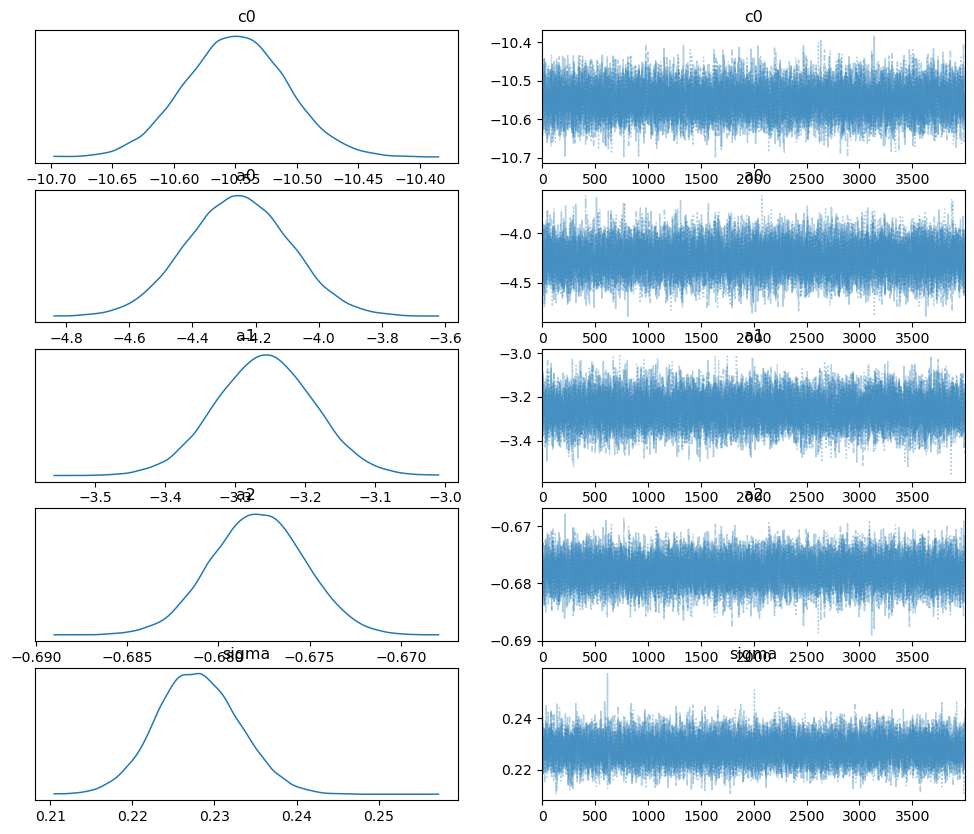

In [20]:
az.plot_trace(traces1[0], combined=True);

In [21]:
marginal_likelihoods = []
log_marginal_likelihoods = []
for i in range(models_stored):
    log_ml_raw = traces1[i].sample_stats["log_marginal_likelihood"].values
    # Flatten possible nested lists and cast to floats
    flattened = []
    for row in log_ml_raw.ravel():
        # If it’s a list, tuple, or NumPy array then flattened.extend(row) appends all items inside it (not the list itself).
        if isinstance(row, (list, tuple, np.ndarray)):
            flattened.extend(row)
        # Otherwise (a plain number or NaN) then flattened.append(row) just adds the single value.
        else:
            flattened.append(row)
    #print(flattened)
    # This ensures that everything inside flattened is a single scalar number, not a list or array.
    log_ml = np.array(flattened, dtype=float)
    # Checks that the entry is effectively a number
    log_ml = log_ml[~np.isnan(log_ml)]
    print(log_ml)
    # Computes the mean
    mean_log_ml = np.mean(log_ml)
    log_marginal_likelihoods.append(mean_log_ml)

[36.82789034 35.82340801 35.35117884 34.8261497 ]
[34.51061834 35.18660751 34.73437123 35.86787115]
[33.11842577 32.0810653  32.29061365 34.73484105]
[17.60868773 17.87161954 19.72022965 19.29629537]
[16.67074485 18.12749214 15.51154745 16.71001495]
[4.45021693 4.57171353 5.56801865 4.46470251]
[-12.40591867 -14.16607874 -13.40122592 -12.17312678]
[-15.01727862 -13.64838758 -12.96163236 -11.14584791]
[-13.27633191 -14.28480595 -12.91588048 -14.38494325]
[-14.76399335 -14.81522309 -13.43925961 -14.47729404]


In [22]:
# Recovers the highest ml value and its related index, i.e. model
max_ml = np.max(log_marginal_likelihoods)
argmax_ml = np.argmax(log_marginal_likelihoods)
max_ml, argmax_ml 

(np.float64(35.707156720451025), np.int64(0))

In [23]:
# Computes the marginal likelihood ratios between the given model and the benchmark
ml_diff = []
for i in range(models_stored):
    ml_diff.append(np.exp(-(log_marginal_likelihoods[argmax_ml] - log_marginal_likelihoods[i])))
ml_diff

[np.float64(1.0),
 np.float64(0.5313737406715371),
 np.float64(0.0705862243006246),
 np.float64(3.810392090236685e-08),
 np.float64(5.877073674105048e-09),
 np.float64(3.642599170735716e-14),
 np.float64(6.7742441595662315e-22),
 np.float64(5.791716503496602e-22),
 np.float64(3.435714573835586e-22),
 np.float64(1.7785044293570028e-22)]

In [24]:
np.argsort(ml_diff)

array([9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

## Best Model

In [ ]:
files = [f"/home/paolo/Thesis/Na/mc_desc_dim_norm_lnD/trace_model_{i}.nc" for i in range(10)]
traces_list = [az.from_netcdf(f) for f in files]
traces1 = traces_list

In [25]:
c0_post = []
a0_post = []
a1_post = []
a2_post = []
models_stored = 10
for m in range(models_stored):
    c0_post.append(np.mean(traces1[m].posterior['c0'].values.flatten()))
    a0_post.append(np.mean(traces1[m].posterior['a0'].values.flatten()))
    a1_post.append(np.mean(traces1[m].posterior['a1'].values.flatten()))
    a2_post.append(np.mean(traces1[m].posterior['a2'].values.flatten()))

In [26]:
c0_post_std = []
a0_post_std = []
a1_post_std = []
a2_post_std = []
for m in range(models_stored):
    c0_post_std.append(np.std(traces1[m].posterior['c0'].values.flatten()))
    a0_post_std.append(np.std(traces1[m].posterior['a0'].values.flatten()))
    a1_post_std.append(np.std(traces1[m].posterior['a1'].values.flatten()))
    a2_post_std.append(np.std(traces1[m].posterior['a2'].values.flatten()))

In [28]:
y_post = []
y_post_test = []
for m in range(models_stored):
    y_post.append(np.array(c0_post[m]) + X[m, 0, :] * np.array(a0_post[m]) + X[m, 1, :] * np.array(a1_post[m]) + X[m, 2, :] * np.array(a2_post[m]))
    y_post_test.append(np.array(c0_post[m]) + X_test[m, 0, :] * np.array(a0_post[m]) + X_test[m, 1, :] * np.array(a1_post[m]) + X_test[m, 2, :] * np.array(a2_post[m]))

In [29]:
y_post = np.array(y_post).T
y_post_test = np.array(y_post_test).T
y_post.shape

(1041, 10)

In [30]:
y_obs = np.tile(data_train['logD'], (10,1)).T
y_obs

array([[-22.44947812, -22.44947812, -22.44947812, ..., -22.44947812,
        -22.44947812, -22.44947812],
       [-22.98888401, -22.98888401, -22.98888401, ..., -22.98888401,
        -22.98888401, -22.98888401],
       [-17.55271247, -17.55271247, -17.55271247, ..., -17.55271247,
        -17.55271247, -17.55271247],
       ...,
       [-22.68866241, -22.68866241, -22.68866241, ..., -22.68866241,
        -22.68866241, -22.68866241],
       [-20.02651   , -20.02651   , -20.02651   , ..., -20.02651   ,
        -20.02651   , -20.02651   ],
       [-24.39240447, -24.39240447, -24.39240447, ..., -24.39240447,
        -24.39240447, -24.39240447]], shape=(1041, 10))

In [31]:
np.sqrt(np.mean((y_obs - y_post)**2, axis = 0))

array([0.2272611 , 0.22758859, 0.2278431 , 0.23100813, 0.23135941,
       0.23430993, 0.23819439, 0.238253  , 0.23829037, 0.23852067])

In [32]:
y_obs_test = np.tile(data_test['logD'], (10,1)).T

In [33]:
np.sqrt(np.mean((y_obs_test - y_post_test)**2, axis = 0))

array([0.22636988, 0.23988453, 0.23995756, 0.2412044 , 0.23144207,
       0.24404647, 0.2587191 , 0.25015808, 0.25829991, 0.25337942])

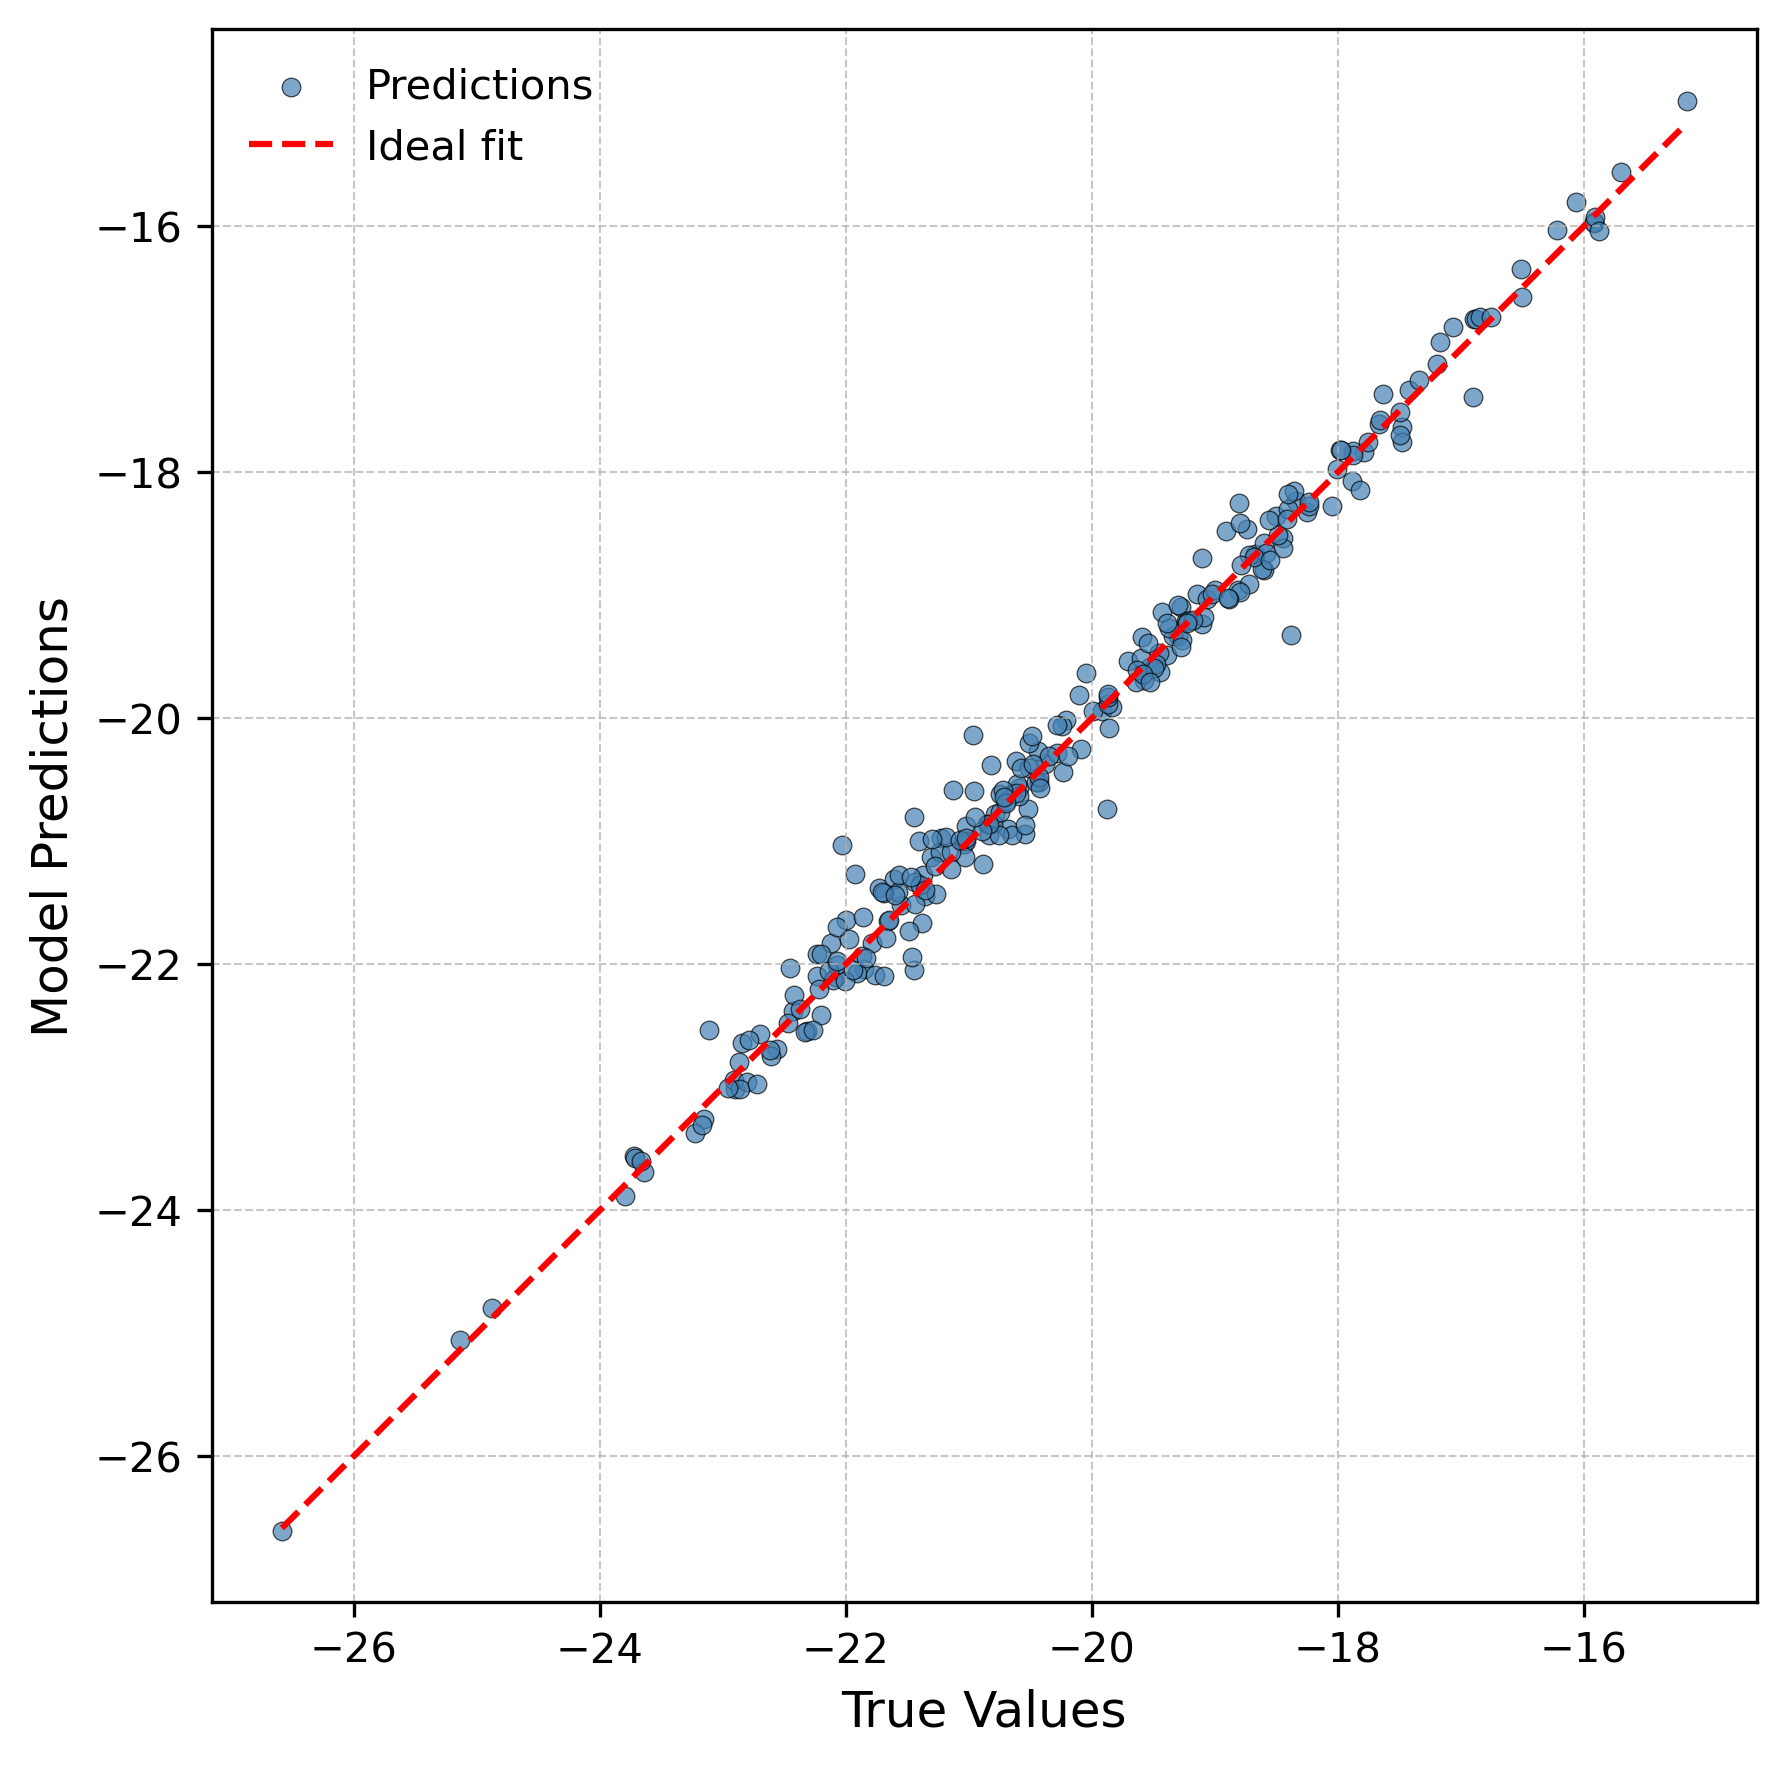

In [34]:
# Create figure with controlled size and resolution
plt.figure(figsize=(6, 6), dpi=300)

# Scatter plot with better styling
plt.scatter(
    data_test['logD'],
    y_post_test.T[0],
    s=20,
    alpha=0.7,
    edgecolors='black',
    linewidths=0.3,
    color='steelblue',
    label='Predictions'
)

# Identity line (perfect prediction)
min_val = min(data_test['logD'].min(), y_post.T[0].min())
max_val = max(data_test['logD'].max(), y_post.T[0].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Ideal fit'
)

# Labels with better formatting
plt.xlabel('True Values', fontsize=12)
plt.ylabel('Model Predictions', fontsize=12)

# Improve ticks and grid
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Equal aspect ratio for fair comparison
plt.gca().set_aspect('equal', adjustable='box')

# Legend
plt.legend(frameon=False, fontsize=10)

# Tight layout for publication
plt.tight_layout()

plt.show()

# E vs Rest

In [6]:
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
data = initialize_units(data_train)
T = 300
EvsRest = pd.DataFrame({
    "sample_id": [f"s{j+1}" for j in range(len(data_train['Ea']))], 
    "rho": data['density'],
    "AAV": data['AAV'],
    "PF": data_train['PF'],
    "VPA": data['VPA'],
    "NBI": data_train['NBI'],
    "SBI": data_train['SBI'],
    "RBI": data_train['RBI'],
    "WE": data_train['weighted_electronegativity'],
    "B": data_train['B'],
    "N": data_train['N'],
    "S": data_train['S'],
    "O": data_train['O'],
    "F": data_train['F'],
    "Na": data_train['Na'],
    "Al": data_train['Al'],
    "Si": data_train['Si'],
    "P": data_train['P'],
    "Cl": data_train['Cl'],
    "Ge": data_train['Ge'],
    "Br": data_train['Br'],
    "I": data_train['I'],

    # Volume
    "cub_root_V" : data['cub_root_V'],
    
    # Na–Na distances
    "Na-Na": data['Na-Na'],
    "Na-Na-max": data['Na-Na-max'],
    "Na-Na-avg": data['Na-Na-avg'],

    # Bottleneck descriptors
    "bottleneck_min": data['bottleneck_min'],
    "bottleneck_avg": data['bottleneck_avg'],

    # Polyhedral distortion
    "poly_dist_max": data_train['poly_dist_max'],
    "poly_dist_std": data_train['poly_dist_std'],
    "poly_dist_avg": data_train['poly_dist_avg'],
    "poly_dist_avg_fixed": data_train['poly_dist_avg_fixed'],

    # Voronoi face areas
    "face-area-max": data['face-area-max'],
    "face-area-avg": data['face-area-avg'],
    "face-area-min": data['face-area-min'],
    "face-area-count": data_train['face-area-count'],

    # Pockets
    "pockets-per-ion": data_train['pockets-per-ion'],
    "pockets-per-volume": data['pockets-per-volume'],

    # Paths
    "paths-per-ion": data_train['paths-per-ion'],
    "paths-per-volume": data['paths-per-volume'],

    # Target
    "E": data['E']
})    

In [7]:
n_feat = 39
EvsRest.to_csv(f"/home/paolo/Thesis/Na/data/final/Na_Ea{n_feat}_temp300_unitless.csv", index=False)
data_file = f"/home/paolo/Thesis/Na/data/final/Na_Ea{n_feat}_temp300_unitless.csv"
os.environ["SISSOPP_TUT_DAT_FILE"] = data_file

In [8]:
# Try the fit with the exact functional form
rung = 2
desc_dim = 3
Diff_json = {
    'data_file': data_file,
     'property_key': 'E',
     'desc_dim': desc_dim,
     'n_sis_select': 10,
     'max_rung': rung,
     'calc_type': 'regression',
     'min_abs_feat_val': 1e-05,
     'max_abs_feat_val': 1e8,
     'n_residual': 10,
     'n_models_store': 10,
     'leave_out_frac': 0.0,
     'leave_out_inds': [],
     'opset': ['exp', 'add', 'sub', 'mult', 'div', 'sin', 'cos']
}
json.dump(Diff_json, open(f"/home/paolo/Thesis/Na/data/final/Ea{n_feat}_{rung}_{desc_dim}_unitless.json", "w"), indent=4)

In [20]:
def extract_rung2_dd3_Ea(ms = 10, rung=2, feat = 39):
    dd = 3
    formulas = []
    a0_list = []
    a1_list = []
    a2_list = []
    a3_list = []
    c0_list = []
    models_stored = ms
    for i in range(models_stored):
        filename = f'/home/paolo/Thesis/Na/data/final/models_Ea{feat}_{rung}_{dd}_unitless/train_dim_{dd}_model_{i}.dat'
        with open(filename, 'r') as f:
            line1 = next(f)               # First line
            for _ in range(4): next(f)    # Skip lines 2 to 5
            line6 = next(f)               # Sixth line
            formula = line1.replace('#', '').strip()
            # Split line6 by spaces
            parts = line6.strip().split()
            a0_i = parts[3].rstrip(',')
            a1_i = parts[4].rstrip(',')
            a2_i = parts[5].rstrip(',')
            c0_i = parts[6].rstrip(',')
    
            formulas.append(formula)
            a0_list.append(a0_i)
            a1_list.append(a1_i)
            a2_list.append(a2_i)
            c0_list.append(c0_i)
            #print(formula, a0_i, a1_i, c0_i)
    return(formulas, a0_list, a1_list, a2_list, c0_list)

In [21]:
raw_formulas2, a0_list2, a1_list2, a2_list2, c0_list2 =extract_rung2_dd3_Ea()
raw_formulas2

['c0 + a0 * ((B + SBI) * (face-area-count + face-area-max)) + a1 * ((Ge * S) + (poly_dist_avg * P)) + a2 * ((O - NBI) * (face-area-avg - poly_dist_avg))',
 'c0 + a0 * ((B + SBI) * (face-area-count + face-area-max)) + a1 * ((Ge * S) + (poly_dist_avg_fixed * P)) + a2 * ((O - NBI) * (face-area-avg - poly_dist_avg))',
 'c0 + a0 * ((B + SBI) * (face-area-count + cub_root_V)) + a1 * ((Ge * S) + (poly_dist_avg * P)) + a2 * ((O - NBI) * (face-area-avg - poly_dist_avg))',
 'c0 + a0 * ((B + SBI) * (face-area-count + cub_root_V)) + a1 * ((Ge * S) + (poly_dist_avg_fixed * P)) + a2 * ((O - NBI) * (face-area-avg - poly_dist_avg))',
 'c0 + a0 * ((B + SBI) * (face-area-count - WE)) + a1 * ((Ge * S) + (poly_dist_avg * P)) + a2 * ((O - NBI) * (face-area-avg - poly_dist_avg))',
 'c0 + a0 * ((B + SBI) * (face-area-count - WE)) + a1 * ((Ge * S) + (poly_dist_avg_fixed * P)) + a2 * ((O - NBI) * (face-area-avg - poly_dist_avg))',
 'c0 + a0 * ((B + SBI) * (face-area-count + bottleneck_avg)) + a1 * ((Ge * S) + 

In [17]:
def sanitize(expr):
    return (
        expr
        .replace('Na-Na-avg', 'Na_Na_avg')
        .replace('Na-Na-max', 'Na_Na_max')
        .replace('Na-Na', 'Na_Na')
        .replace('face-area-avg', 'face_area_avg')
        .replace('face-area-max', 'face_area_max')
        .replace('face-area-min', 'face_area_min')
        .replace('face-area-count', 'face_area_count')
        .replace('cub_root_V', 'cub_root_V')
        .replace('pockets-per-ion', 'pockets_per_ion')
        .replace('pockets-per-volume', 'pockets_per_volume')
        .replace('paths-per-ion', 'paths_per_ion')
        .replace('paths-per-volume', 'paths_per_volume')
    )

In [18]:
formulas2 = [sanitize(f) for f in raw_formulas2]
formulas2

['c0 + a0 * ((B + SBI) * (face_area_count + face_area_max)) + a1 * ((Ge * S) + (poly_dist_avg * P)) + a2 * ((O - NBI) * (face_area_avg - poly_dist_avg))',
 'c0 + a0 * ((B + SBI) * (face_area_count + face_area_max)) + a1 * ((Ge * S) + (poly_dist_avg_fixed * P)) + a2 * ((O - NBI) * (face_area_avg - poly_dist_avg))',
 'c0 + a0 * ((B + SBI) * (face_area_count + cub_root_V)) + a1 * ((Ge * S) + (poly_dist_avg * P)) + a2 * ((O - NBI) * (face_area_avg - poly_dist_avg))',
 'c0 + a0 * ((B + SBI) * (face_area_count + cub_root_V)) + a1 * ((Ge * S) + (poly_dist_avg_fixed * P)) + a2 * ((O - NBI) * (face_area_avg - poly_dist_avg))',
 'c0 + a0 * ((B + SBI) * (face_area_count - WE)) + a1 * ((Ge * S) + (poly_dist_avg * P)) + a2 * ((O - NBI) * (face_area_avg - poly_dist_avg))',
 'c0 + a0 * ((B + SBI) * (face_area_count - WE)) + a1 * ((Ge * S) + (poly_dist_avg_fixed * P)) + a2 * ((O - NBI) * (face_area_avg - poly_dist_avg))',
 'c0 + a0 * ((B + SBI) * (face_area_count + bottleneck_avg)) + a1 * ((Ge * S) + 

In [22]:
a0_2 = np.array(a0_list2, dtype=float)
a1_2 = np.array(a1_list2, dtype=float)
a2_2 = np.array(a2_list2, dtype=float)
c0_2 = np.array(c0_list2, dtype=float)

In [26]:
# define symbols
a0_sym, a1_sym, a2_sym, c0_sym = sp.symbols('a0 a1 a2 c0')
symbols = sp.symbols(
    '''
    Ea B N O F Na Al Si P S Cl Ge Br I
    rho AAV PF SBI RBI VPA NBI WE cub_root_V
    bottleneck_min bottleneck_avg
    poly_dist_avg poly_dist_max poly_dist_std poly_dist_avg_fixed
    Na_Na Na_Na_max Na_Na_avg
    face_area_max face_area_avg face_area_min face_area_count
    pockets_per_ion pockets_per_volume
    paths_per_ion paths_per_volume
    '''
)

locals_dict = {s.name: s for s in symbols}
# convert strings to sympy expressions
sympy_exprs = [sp.sympify(f, locals=locals_dict) for f in formulas2]

pruned = []
# Prunes the coefficients that will be added later as distributions
for f in sympy_exprs:
    row = [
        sp.simplify(f.coeff(a0_sym)),
        sp.simplify(f.coeff(a1_sym)),
        sp.simplify(f.coeff(a2_sym)),
    ]
    pruned.append(row)

pruned

[[(B + SBI)*(face_area_count + face_area_max),
  Ge*S + P*poly_dist_avg,
  -(NBI - O)*(face_area_avg - poly_dist_avg)],
 [(B + SBI)*(face_area_count + face_area_max),
  Ge*S + P*poly_dist_avg_fixed,
  -(NBI - O)*(face_area_avg - poly_dist_avg)],
 [(B + SBI)*(cub_root_V + face_area_count),
  Ge*S + P*poly_dist_avg,
  -(NBI - O)*(face_area_avg - poly_dist_avg)],
 [(B + SBI)*(cub_root_V + face_area_count),
  Ge*S + P*poly_dist_avg_fixed,
  -(NBI - O)*(face_area_avg - poly_dist_avg)],
 [-(B + SBI)*(WE - face_area_count),
  Ge*S + P*poly_dist_avg,
  -(NBI - O)*(face_area_avg - poly_dist_avg)],
 [-(B + SBI)*(WE - face_area_count),
  Ge*S + P*poly_dist_avg_fixed,
  -(NBI - O)*(face_area_avg - poly_dist_avg)],
 [(B + SBI)*(bottleneck_avg + face_area_count),
  Ge*S + P*poly_dist_avg_fixed,
  -(NBI - O)*(face_area_avg - poly_dist_avg)],
 [(B + SBI)*(bottleneck_avg + face_area_count),
  Ge*S + P*poly_dist_avg,
  -(NBI - O)*(face_area_avg - poly_dist_avg)],
 [(AAV + face_area_count)*(B + SBI),
  G

In [27]:
vars_ = [
    locals_dict[k] for k in [
        'B', 'N', 'S', 'O', 'F', 'Na', 'Al', 'Si', 'P', 'Cl', 'Ge', 'Br', 'I', 'rho', 'AAV', 'PF', 'NBI', 'SBI', 'RBI', 'VPA', 'WE', 'cub_root_V', 
        'Na_Na', 'Na_Na_max', 'Na_Na_avg', 'bottleneck_min', 'bottleneck_avg', 'poly_dist_max', 'poly_dist_std', 'poly_dist_avg', 'poly_dist_avg_fixed',
        'face_area_max', 'face_area_avg', 'face_area_min', 'face_area_count', 
        'pockets_per_ion', 'pockets_per_volume', 'paths_per_ion', 'paths_per_volume',
    ]
]
# Feature functions
Phi = [
    sp.lambdify(vars_, row, modules="numpy")
    for row in pruned
]

In [28]:
data = initialize_units(data_train)
X = np.array([
    phi(
        data_train['B'],
        data_train['N'],
        data_train['S'],
        data_train['O'],
        data_train['F'],
        data_train['Na'],
        data_train['Al'],
        data_train['Si'],
        data_train['P'],
        data_train['Cl'],
        data_train['Ge'],
        data_train['Br'],
        data_train['I'],
        
        data['density'],
        data['AAV'],
        data_train['PF'],
        data_train['NBI'],
        data_train['SBI'],
        data_train['RBI'],
        data['VPA'],
        data_train['weighted_electronegativity'],
        
        
        # Volume
        data['cub_root_V'],
        
        # Na–Na distances
        data['Na-Na'],
        data['Na-Na-max'],
        data['Na-Na-avg'],
        
        # Bottleneck descriptors
        data['bottleneck_min'],
        data['bottleneck_avg'],
        
        # Polyhedral distortion
        data_train['poly_dist_max'],
        data_train['poly_dist_std'],
        data_train['poly_dist_avg'],
        data_train['poly_dist_avg_fixed'],
        
        # Voronoi face areas
        data['face-area-max'],
        data['face-area-avg'],
        data['face-area-min'],
        data_train['face-area-count'],
        
        # Pockets
        data_train['pockets-per-ion'],
        data['pockets-per-volume'],
        
        # Paths
        data_train['paths-per-ion'],
        data['paths-per-volume'],
    )
    for phi in Phi
])

In [29]:
data2 = initialize_units(data_test)
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
T = 300
X_test = np.array([
    phi(
        data_test['B'],
        data_test['N'],
        data_test['S'],
        data_test['O'],
        data_test['F'],
        data_test['Na'],
        data_test['Al'],
        data_test['Si'],
        data_test['P'],
        data_test['Cl'],
        data_test['Ge'],
        data_test['Br'],
        data_test['I'],
        
        data2['density'],
        data2['AAV'],
        data_test['PF'],
        data_test['NBI'],
        data_test['SBI'],
        data_test['RBI'],
        data2['VPA'],
        data_test['weighted_electronegativity'],
        
        
        # Volume
        data2['cub_root_V'],
        
        # Na–Na distances
        data2['Na-Na'],
        data2['Na-Na-max'],
        data2['Na-Na-avg'],
        
        # Bottleneck descriptors
        data2['bottleneck_min'],
        data2['bottleneck_avg'],
        
        # Polyhedral distortion
        data_test['poly_dist_max'],
        data_test['poly_dist_std'],
        data_test['poly_dist_avg'],
        data_test['poly_dist_avg_fixed'],
        
        # Voronoi face areas
        data2['face-area-max'],
        data2['face-area-avg'],
        data2['face-area-min'],
        data_test['face-area-count'],
        
        # Pockets
        data_test['pockets-per-ion'],
        data2['pockets-per-volume'],
        
        # Paths
        data_test['paths-per-ion'],
        data2['paths-per-volume'],
    )
    for phi in Phi
])

In [30]:
traces2 = []
ppcs2 = []
models_stored = 10
for i in range(models_stored):
    with pm.Model() as model:
        # Select the i-th column
        f = X[i, :, :]
        f_test = X_test[i, :, :]

        # Priors, Che valori di sigma potrei usare? 10 forse è un po' troppo
        c0_coeff = pm.Normal("c0", mu=c0_2[i], sigma=10)
        a0_coeff = pm.Normal("a0", mu=a0_2[i], sigma=10)
        a1_coeff = pm.Normal("a1", mu=a1_2[i], sigma=10)
        a2_coeff = pm.Normal("a2", mu=a2_2[i], sigma=10)
        sigma = pm.HalfNormal("sigma", sigma=2)

        # Linear parametrization
        mu = c0_coeff + a0_coeff * f[0, :] + a1_coeff * f[1, :] + a2_coeff * f[2, :]

        # Likelihood
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=data['E'])

        # Sample from posterior
        # Sequential montecarlo chiedi spiegazione
        trace = pm.smc.sample_smc(draws=4000, chains=4, threshold=0.5, random_seed = 123)

        # Posterior predictive for the TEST set:
        # Create a new RV for test predictions using the same parameters.
        mu_test = pm.Deterministic("mu_test", c0_coeff + a0_coeff * f_test[0, :] + a1_coeff * f_test[1, :] + a2_coeff * f_test[2, :])
        y_test_rv = pm.Normal("y_test", mu=mu_test, sigma=sigma)
        
        ppc = pm.sample_posterior_predictive(
        trace,
        var_names=["y_test"],
        random_seed=123
    )
        
        #trace = pm.sample()
        traces2.append(trace)
        ppcs2.append(ppc)
        
        idata = trace.posterior
        az.to_netcdf(idata, f"trace2_model_{i}.nc")
        az.to_netcdf(ppc, f"pp2_model_{i}.nc")

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Sampling: [y_test]


Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


...

Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Sampling: [y_test]


Output()

In [31]:
marginal_likelihoods = []
log_marginal_likelihoods = []
for i in range(models_stored):
    log_ml_raw = traces2[i].sample_stats["log_marginal_likelihood"].values
    # Flatten possible nested lists and cast to floats
    flattened = []
    for row in log_ml_raw.ravel():
        # If it’s a list, tuple, or NumPy array then flattened.extend(row) appends all items inside it (not the list itself).
        if isinstance(row, (list, tuple, np.ndarray)):
            flattened.extend(row)
        # Otherwise (a plain number or NaN) then flattened.append(row) just adds the single value.
        else:
            flattened.append(row)
    #print(flattened)
    # This ensures that everything inside flattened is a single scalar number, not a list or array.
    log_ml = np.array(flattened, dtype=float)
    # Checks that the entry is effectively a number
    log_ml = log_ml[~np.isnan(log_ml)]
    print(log_ml)
    # Computes the mean
    mean_log_ml = np.mean(log_ml)
    log_marginal_likelihoods.append(mean_log_ml)

[-978.63884978 -978.64263209 -978.54118773 -978.68513629]
[-978.62153745 -978.91525596 -978.31966085 -978.43971491]
[-978.95921775 -979.02855881 -979.48965374 -978.45144225]
[-979.45434977 -979.46249274 -979.25358104 -978.80470546]
[-979.21437717 -979.84840363 -977.89760467 -979.20398758]
[-979.46872584 -979.26503341 -977.94510655 -978.75843976]
[-979.75988927 -978.95949195 -980.09749518 -979.29501669]
[-980.22524288 -979.2331355  -980.05331588 -979.76478391]
[-979.81211308 -979.41848317 -979.32310878 -979.96429093]
[-979.59500392 -980.03482436 -980.34803331 -979.7851918 ]


In [32]:
# Recovers the highest ml value and its related index, i.e. model
max_ml = np.max(log_marginal_likelihoods)
argmax_ml = np.argmax(log_marginal_likelihoods)
max_ml, argmax_ml

(np.float64(-978.574042292658), np.int64(1))

In [33]:
# Computes the marginal likelihood ratios between the given model and the benchmark
ml_diff = []
for i in range(models_stored):
    ml_diff.append(np.exp(-(log_marginal_likelihoods[argmax_ml] - log_marginal_likelihoods[i])))
ml_diff

[np.float64(0.9484661471145514),
 np.float64(1.0),
 np.float64(0.6648619553068281),
 np.float64(0.5118416605532172),
 np.float64(0.6268481406209523),
 np.float64(0.751800639775945),
 np.float64(0.3852237363680257),
 np.float64(0.28791866609843314),
 np.float64(0.3480334453445617),
 np.float64(0.2549415295633073)]

In [34]:
np.argsort(ml_diff)

array([9, 7, 8, 6, 3, 4, 2, 5, 0, 1])

## Best Model

In [ ]:
files = [f"/home/paolo/Thesis/Na/mc_norm_rung_2_dd3_Ea/trace2_model_{i}.nc" for i in range(10)]
traces_list = [az.from_netcdf(f) for f in files]
traces1 = traces_list

In [35]:
c0_post = []
a0_post = []
a1_post = []
a2_post = []
for m in range(models_stored):
    c0_post.append(np.mean(traces2[m].posterior['c0'].values.flatten()))
    a0_post.append(np.mean(traces2[m].posterior['a0'].values.flatten()))
    a1_post.append(np.mean(traces2[m].posterior['a1'].values.flatten()))
    a2_post.append(np.mean(traces2[m].posterior['a2'].values.flatten()))

In [36]:
c0_post_std = []
a0_post_std = []
a1_post_std = []
a2_post_std = []
for m in range(models_stored):
    c0_post_std.append(np.std(traces2[m].posterior['c0'].values.flatten()))
    a0_post_std.append(np.std(traces2[m].posterior['a0'].values.flatten()))
    a1_post_std.append(np.std(traces2[m].posterior['a1'].values.flatten()))
    a2_post_std.append(np.std(traces2[m].posterior['a2'].values.flatten()))

In [37]:
y_post = []
y_post_test = []
for m in range(models_stored):
    y_post.append(np.array(c0_post[m]) + X[m, 0, :] * np.array(a0_post[m]) + X[m, 1, :] * np.array(a1_post[m]) + X[m, 2, :] * np.array(a2_post[m]))
    y_post_test.append(np.array(c0_post[m]) + X_test[m, 0, :] * np.array(a0_post[m]) + X_test[m, 1, :] * np.array(a1_post[m]) + X_test[m, 2, :] * np.array(a2_post[m]))

In [38]:
y_post = np.array(y_post).T
y_post_test = np.array(y_post_test).T
y_post.shape

(1041, 10)

In [39]:
y_obs = np.tile(data['E'], (10,1)).T
y_obs

array([[ 0.67745724,  0.67745724,  0.67745724, ...,  0.67745724,
         0.67745724,  0.67745724],
       [ 1.96787596,  1.96787596,  1.96787596, ...,  1.96787596,
         1.96787596,  1.96787596],
       [-1.2712852 , -1.2712852 , -1.2712852 , ..., -1.2712852 ,
        -1.2712852 , -1.2712852 ],
       ...,
       [ 1.28468464,  1.28468464,  1.28468464, ...,  1.28468464,
         1.28468464,  1.28468464],
       [ 0.0324672 ,  0.0324672 ,  0.0324672 , ...,  0.0324672 ,
         0.0324672 ,  0.0324672 ],
       [ 2.49603244,  2.49603244,  2.49603244, ...,  2.49603244,
         2.49603244,  2.49603244]], shape=(1041, 10))

In [40]:
# train RMSE
RMSE_train = np.sqrt(np.mean((y_obs - y_post)**2, axis = 0))
RMSE_train

array([0.60399432, 0.60402436, 0.60419234, 0.60422374, 0.60426235,
       0.60430096, 0.60452428, 0.60453145, 0.6046042 , 0.6046203 ])

In [47]:
# train R^2
from sklearn.metrics import r2_score

r2_score(y_obs.T[0], y_post.T[0]), r2_score(y_obs.T[6], y_post.T[6])

(0.6348400888554462, 0.6341990021784014)

In [41]:
y_obs_test = np.tile(data2['E'], (10,1)).T
y_obs_test

array([[-0.64586049, -0.64586049, -0.64586049, ..., -0.64586049,
        -0.64586049, -0.64586049],
       [ 0.43108133,  0.43108133,  0.43108133, ...,  0.43108133,
         0.43108133,  0.43108133],
       [-1.40381703, -1.40381703, -1.40381703, ..., -1.40381703,
        -1.40381703, -1.40381703],
       ...,
       [-0.45995973, -0.45995973, -0.45995973, ..., -0.45995973,
        -0.45995973, -0.45995973],
       [ 0.42330327,  0.42330327,  0.42330327, ...,  0.42330327,
         0.42330327,  0.42330327],
       [ 0.4496343 ,  0.4496343 ,  0.4496343 , ...,  0.4496343 ,
         0.4496343 ,  0.4496343 ]], shape=(261, 10))

In [42]:
# test RMSE
RMSE_test = np.sqrt(np.mean((y_obs_test - y_post_test)**2, axis = 0))
RMSE_test

array([0.60693536, 0.60695231, 0.60727096, 0.60726798, 0.60715896,
       0.60715046, 0.60620975, 0.6063149 , 0.60739216, 0.60693473])

In [46]:
# test R^2
r2_score(y_obs_test.T[0], y_post_test.T[0]), r2_score(y_obs_test.T[6], y_post_test.T[6])

(0.6302126533786816, 0.631096318074934)

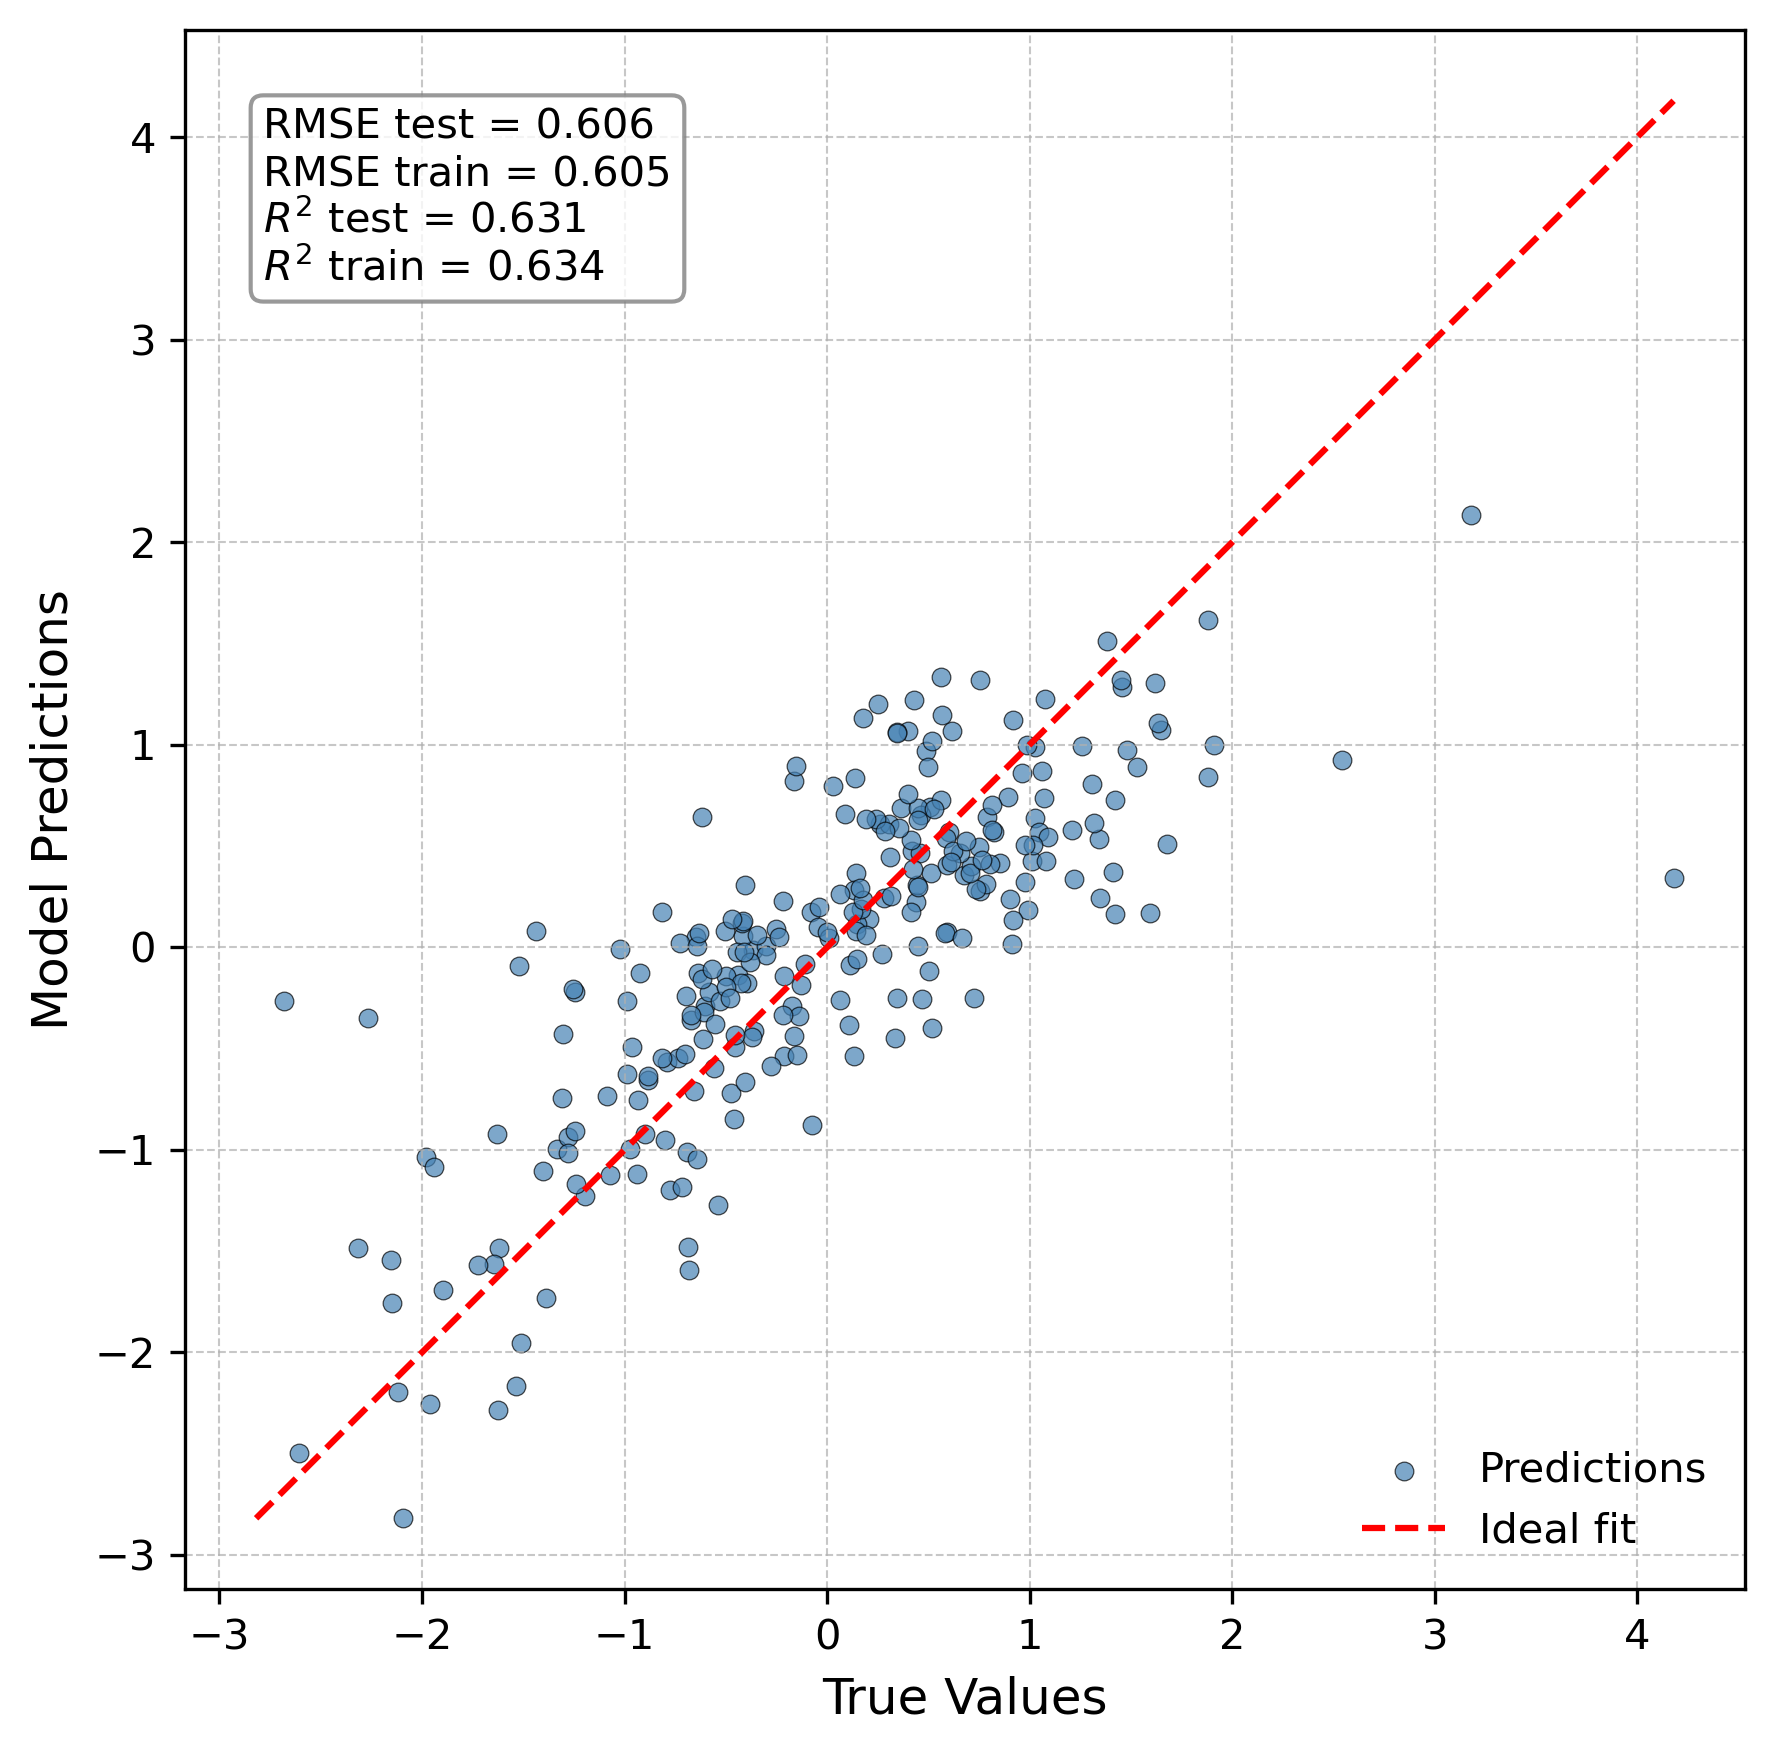

In [48]:
data2 = initialize_units(data_test)
plt.figure(figsize=(6, 6), dpi=300)

# Scatter plot 
plt.scatter(
    data2['E'],
    y_post_test.T[6],
    s=20,
    alpha=0.7,
    edgecolors='black',
    linewidths=0.3,
    color='steelblue',
    label='Predictions'
)

# Identity line (perfect prediction)
min_val = min(data2['E'].min(), y_post_test.T[6].min())
max_val = max(data2['E'].max(), y_post_test.T[6].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Ideal fit'
)


plt.xlabel('True Values', fontsize=12)
plt.ylabel('Model Predictions', fontsize=12)


plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


textstr = f'RMSE test = {RMSE_test[6]:.3f}\nRMSE train = {RMSE_train[6]:.3f}\n$R^2$ test = {r2_score(y_obs_test.T[6], y_post_test.T[6]):.3f}\n$R^2$ train = {r2_score(y_obs.T[6], y_post.T[6]):.3f}'

plt.text(
    0.05, 0.95, textstr,             # position in axes coordinates
    transform=plt.gca().transAxes,   # use relative positioning (0–1)
    fontsize=10,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.8,
        edgecolor='gray'
    )
)


plt.gca().set_aspect('equal', adjustable='box')

# Legend
plt.legend(frameon=False, fontsize=10)


plt.tight_layout()

plt.savefig('best_model_Ea_fin.pdf')

plt.show()

## Calibration

In [49]:
np.random.seed(10)
c0_samples_list = []
a0_samples_list = []
a1_samples_list = []
a2_samples_list = []
sigma_samples_list = []
for m in range(models_stored):
# Draws 200 samples of the parameters from the posterior distribution
    c0_samples_list.append(np.random.choice(traces2[m].posterior['c0'].values.flatten(), size=200, replace=True))
    a0_samples_list.append(np.random.choice(traces2[m].posterior['a0'].values.flatten(), size=200, replace=True))
    a1_samples_list.append(np.random.choice(traces2[m].posterior['a1'].values.flatten(), size=200, replace=True))
    a2_samples_list.append(np.random.choice(traces2[m].posterior['a2'].values.flatten(), size=200, replace=True))
    sigma_samples_list.append(np.random.choice(traces2[m].posterior['sigma'].values.flatten(), size=200, replace=True))
c0_samples = np.array(c0_samples_list).T
a0_samples = np.array(a0_samples_list).T
a1_samples = np.array(a1_samples_list).T
a2_samples = np.array(a2_samples_list).T
sigma_samples = np.array(sigma_samples_list).T

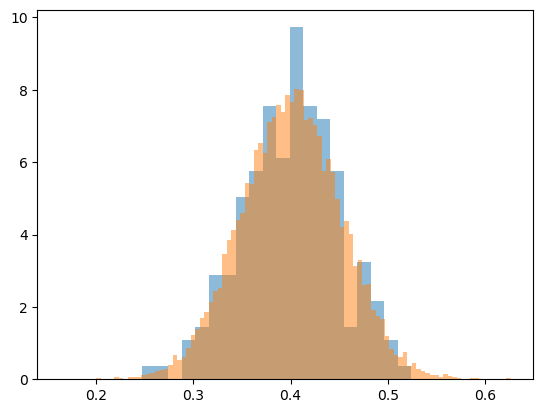

In [50]:
plt.hist(np.array(c0_samples.T[0]), alpha = 0.5, bins = 20, density = True)
plt.hist(traces2[0].posterior['c0'].values.flatten(), bins = 100, alpha = 0.5, density = True)
plt.show()

In [51]:
inputs = 1041
y_emp = np.zeros((inputs, models_stored))
for i in range(inputs):
    for m in range(models_stored):
        # Computes the mean over the ensemble for each of the 1041 points for each of the 10 formulas
        f = X[m, :, :]
        y_emp[i, m] = np.mean(c0_samples[:,m] + X[m, 0, i] * a0_samples[:,m] + X[m, 1, i] * a1_samples[:,m] + X[m, 2, i] * a2_samples[:,m])
# Empirical mean over the models
y_emp

array([[ 0.46621495,  0.46926195,  0.46747621, ...,  0.46614505,
         0.46752904,  0.46090992],
       [ 0.60254546,  0.60552469,  0.59912847, ...,  0.61270899,
         0.59937696,  0.59647596],
       [-1.20427925, -1.20734086, -1.22408815, ..., -1.20582141,
        -1.22039286, -1.21133969],
       ...,
       [ 0.41598784,  0.41458015,  0.41944956, ...,  0.3916581 ,
         0.40321347,  0.41104516],
       [ 0.03410327,  0.0373903 ,  0.03633087, ...,  0.04403523,
         0.03540763,  0.03066076],
       [ 1.05957106,  1.059915  ,  1.05467394, ...,  1.06802691,
         1.0606378 ,  1.05974439]], shape=(1041, 10))

In [52]:
inputs = 1041
var_emp = np.zeros((inputs, models_stored))
for i in range(inputs):
    for m in range(models_stored):
        # Computes the variance over the ensemble for each of the 1041 points for each of the 10 formulas
        #var_emp[i, m] = np.var((c0_samples + Phi[i, m] * a0_samples + sigma_samples - y_emp[i,m])**2), ddof = 1)
        # Assuming decorrelation between noise and parameters
        f = X[m, :, :]
        var_emp[i, m] = 1/(200-1) * np.sum((c0_samples[:,m] + X[m, 0, i] * a0_samples[:,m] + X[m, 1, i] * a1_samples[:,m] + X[m, 2, i] * a2_samples[:,m] - y_emp[i,m])**2 
                                           + sigma_samples[:,m]**2)
# Empirical variance over the models
var_emp

array([[0.37504327, 0.37539672, 0.37748902, ..., 0.37721182, 0.37815159,
        0.37643031],
       [0.37331876, 0.37341714, 0.37581187, ..., 0.37529384, 0.37634203,
        0.3746259 ],
       [0.37718601, 0.3777445 , 0.37930887, ..., 0.37871273, 0.3786635 ,
        0.3764106 ],
       ...,
       [0.37403845, 0.37365407, 0.37616744, ..., 0.37643402, 0.37617473,
        0.37445377],
       [0.37331579, 0.37318963, 0.37551035, ..., 0.37510114, 0.37547439,
        0.37371977],
       [0.37246213, 0.37193403, 0.37477169, ..., 0.37455876, 0.37477783,
        0.37325644]], shape=(1041, 10))

In [53]:
y_obs = np.tile(data['E'], (10,1)).T
y_obs

array([[ 0.67745724,  0.67745724,  0.67745724, ...,  0.67745724,
         0.67745724,  0.67745724],
       [ 1.96787596,  1.96787596,  1.96787596, ...,  1.96787596,
         1.96787596,  1.96787596],
       [-1.2712852 , -1.2712852 , -1.2712852 , ..., -1.2712852 ,
        -1.2712852 , -1.2712852 ],
       ...,
       [ 1.28468464,  1.28468464,  1.28468464, ...,  1.28468464,
         1.28468464,  1.28468464],
       [ 0.0324672 ,  0.0324672 ,  0.0324672 , ...,  0.0324672 ,
         0.0324672 ,  0.0324672 ],
       [ 2.49603244,  2.49603244,  2.49603244, ...,  2.49603244,
         2.49603244,  2.49603244]], shape=(1041, 10))

In [54]:
# Columnwise mean of the given vector, i.e. mean over the features
R = np.mean((y_obs - y_emp)**2/var_emp, axis = 0)
R

array([0.97440377, 0.97468076, 0.96907654, 0.97200891, 0.96856789,
       0.97319969, 0.97177888, 0.97093025, 0.97045844, 0.97524678])

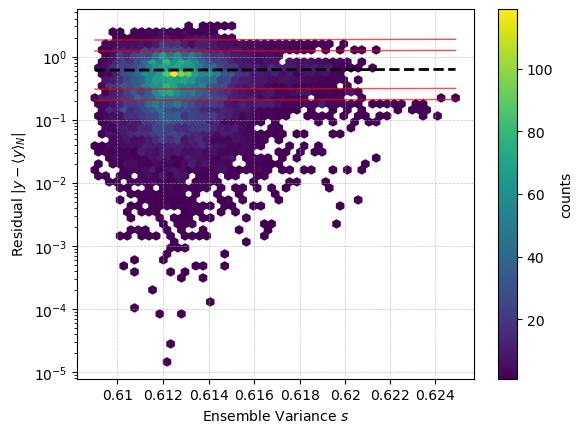

In [64]:
x = np.sqrt(var_emp)  # predicted uncertainty
y = np.abs(y_obs - y_emp)  # empirical error (not squared)

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# reference line y = x 
xmin, xmax = x.min(), x.max()
xline = np.logspace(np.log10(xmin), np.log10(xmax), 300)
plt.plot(xline, xline, 'k--', lw=2, label=r'$y = \hat{\sigma}$')

# sigma lines: y = n·σ
sigma_multipliers = [1/3, 1/2, 2, 3]
for n in sigma_multipliers:
    plt.plot(xline, n * xline,
             linestyle='-',
             color='red',
             lw=1,
             alpha=0.7)

# hexbin
plt.hexbin(x, y, gridsize=50, xscale='log', yscale='log',
           mincnt=1, cmap='viridis')
plt.colorbar(label='counts')
plt.xlabel(r'Ensemble Variance $s$')
plt.ylabel(r'Residual $| y - \langle y \rangle_N|$')
plt.xscale('log')
plt.yscale('log')
plt.xticks([0.61, 0.612, 0.614, 0.616, 0.618, 0.62, 0.622, 0.624], ['0.61', '0.612', '0.614', '0.616', '0.618', '0.62', '0.622', '0.624'])
#plt.legend()
plt.show()

In [ ]:
files_ppc2 = [f"/home/paolo/Thesis/Na/pp_norm_rung_2_dd3_Ea/pp_model_{i}.nc" for i in range(10)]
ppcs2 = [az.from_netcdf(f) for f in files_ppc2]

In [65]:
# ----------------------------
# Metric: W_alpha or Prediction Interval Coverage Probability (PICP)
# ----------------------------
def within_alpha(y_true, y_pred_samples, alpha: float, axis_draws=(0, 1)):
    """
    W_alpha: proportion of y_true inside the central alpha predictive interval.

    y_pred_samples shape examples:
      (chain, draw, n_obs)  -> axis_draws=(0,1)
      (draw, n_obs)         -> axis_draws=(0,)
    """
    y_true = np.asarray(y_true)

    if not (0.0 < alpha < 1.0):
        raise ValueError("alpha must be in (0, 1), e.g. 0.50 or 0.95. It represents a fraction!")

    # Centering of the uncertainty --> If alpha=95 then 5% of the observations will fall outside this interval and they will be split into le lowest and highest quantiles
    # the lowest quantile will be 5/2 = 2.5 and the highest quantile 100 - 2.5 = 97.5
    q_low = (1.0 - alpha) / 2.0
    q_high = 1.0 - q_low

    lower = np.quantile(y_pred_samples, q_low, axis=axis_draws)
    upper = np.quantile(y_pred_samples, q_high, axis=axis_draws)

    # Checks whether the true value lies inside the given interval
    inside = (y_true >= lower) & (y_true <= upper)
    # Computes the mean over the inner values
    return float(np.mean(inside)), lower, upper

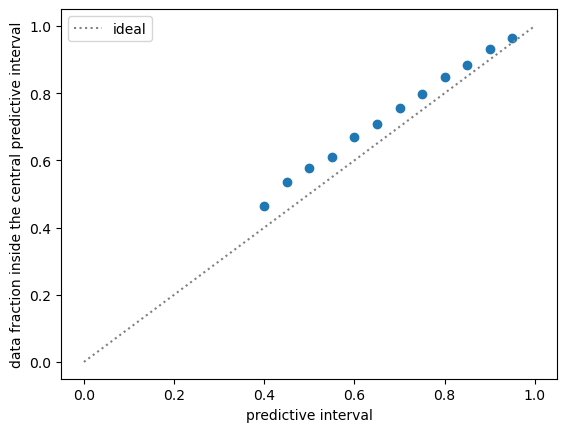

In [68]:
walphas=[]
y_test = np.array(data2['E'])
alphas = np.arange(0.4,1.0,0.05)
for alpha in alphas:
    walpha, _, _ = within_alpha(y_test, ppcs2[6].posterior_predictive["y_test"].values, alpha=alpha, axis_draws=(0, 1))
    walphas.append(walpha)


plt.scatter(alphas,walphas)
plt.ylabel('data fraction inside the central predictive interval')
plt.xlabel('predictive interval')
plt.plot([0,1],[0,1],linestyle=':',color='gray',label='ideal')
plt.legend()
#plt.savefig('within.png')
plt.show()